In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
# CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Flatten labels
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 77s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [3]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

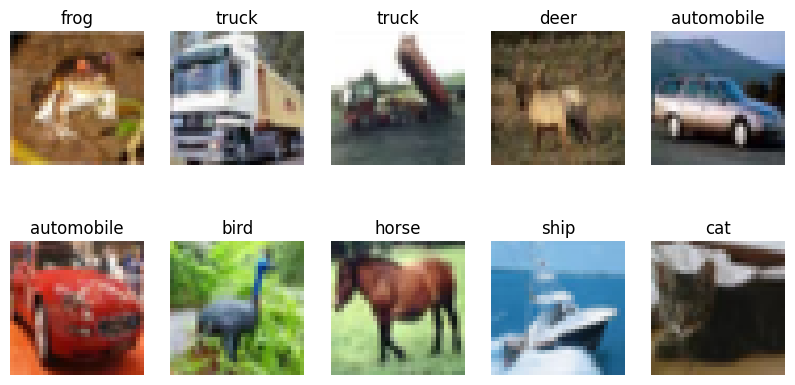

In [6]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [7]:
model = keras.Sequential([

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3374 - loss: 1.8393 - val_accuracy: 0.4158 - val_loss: 1.8198
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4271 - loss: 1.5715 - val_accuracy: 0.5368 - val_loss: 1.2828
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4841 - loss: 1.4326 - val_accuracy: 0.5226 - val_loss: 1.2801
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5319 - loss: 1.3283 - val_accuracy: 0.5878 - val_loss: 1.1701
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5587 - loss: 1.2549 - val_accuracy: 0.6000 - val_loss: 1.1367
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5835 - loss: 1.1916 - val_accuracy: 0.5734 - val_loss: 1.2383
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5999 - loss: 1.1397 - val_accuracy: 0.6132 - val_loss: 1.1201
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6173 - loss: 1.0973 - val_acc

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6501 - loss: 1.0597
Test Accuracy: 0.6500999927520752


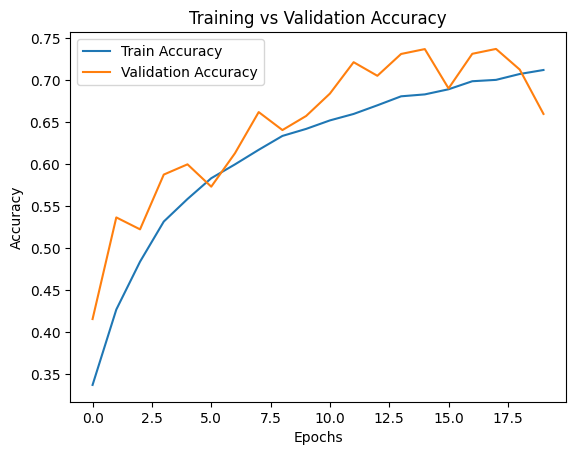

In [11]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


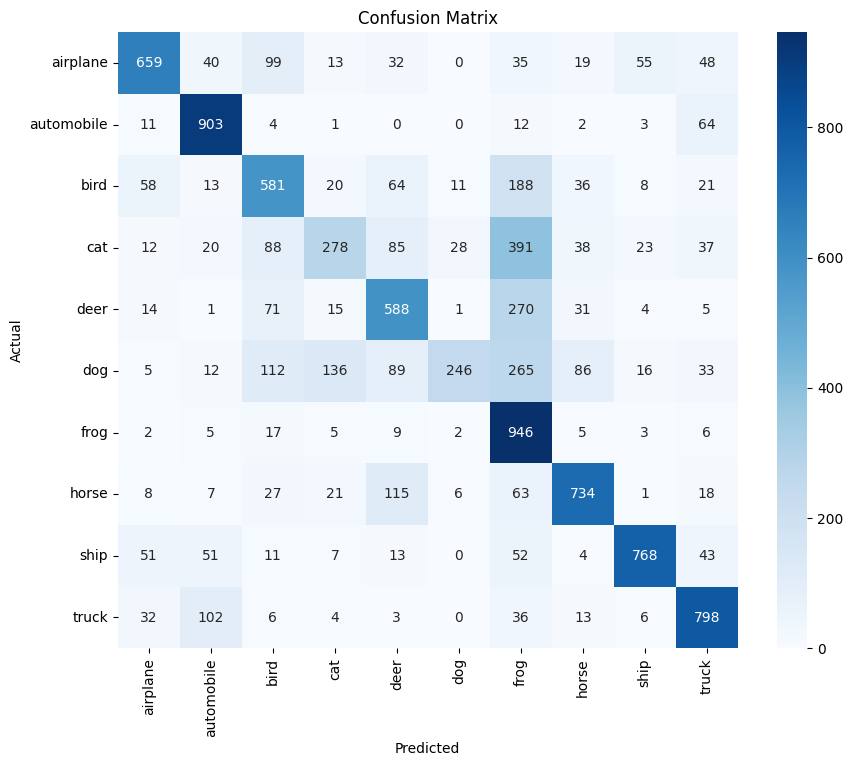

In [12]:
y_pred = np.argmax(model.predict(x_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.77      0.66      0.71      1000
  automobile       0.78      0.90      0.84      1000
        bird       0.57      0.58      0.58      1000
         cat       0.56      0.28      0.37      1000
        deer       0.59      0.59      0.59      1000
         dog       0.84      0.25      0.38      1000
        frog       0.42      0.95      0.58      1000
       horse       0.76      0.73      0.75      1000
        ship       0.87      0.77      0.81      1000
       truck       0.74      0.80      0.77      1000

    accuracy                           0.65     10000
   macro avg       0.69      0.65      0.64     10000
weighted avg       0.69      0.65      0.64     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
Predicted: airplane


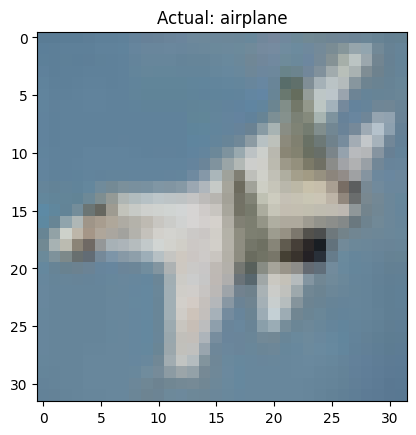

In [14]:
index = 10

plt.imshow(x_test[index])
plt.title(f"Actual: {class_names[y_test[index]]}")

pred = np.argmax(model.predict(x_test[index].reshape(1,32,32,3)))
print("Predicted:", class_names[pred])